<a href="https://colab.research.google.com/github/Sonia1895/PROCESAMIENTO_CLASIFICACION_DATOS/blob/main/Tarea_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteccion de centros de objetos circulares
## Aplicacion a radiografias dentales (deteccion de posibles caries)

Este notebook adapta el ejercicio de deteccion de circulos visto en clase (el ejemplo de las monedas con Hough Circles) a un caso distinto: radiografias dentales, donde las caries suelen verse como manchas oscuras (radiolucidas) de forma mas o menos redondeada dentro del diente.

**Nota importante:** este es un ejercicio de procesamiento de imagenes para la materia, no una herramienta de diagnostico. Los "candidatos" que detecta el algoritmo pueden incluir espacios interproximales, restauraciones u otras estructuras normales, no solo caries reales. Un diagnostico real requiere un profesional de salud dental.

## Obtención de la imagen



Usamos una radiografia panoramica de un dataset publico (proyecto MLUA, segmentación de caries en radiografias panoramicas dentales, disponible en https://github.com/Zzz512/MLUA). La descargamos directamente desde GitHub para que el notebook sea reproducible en Colab sin necesidad de subir archivos.



Dimensiones de la imagen: (768, 1536, 3)


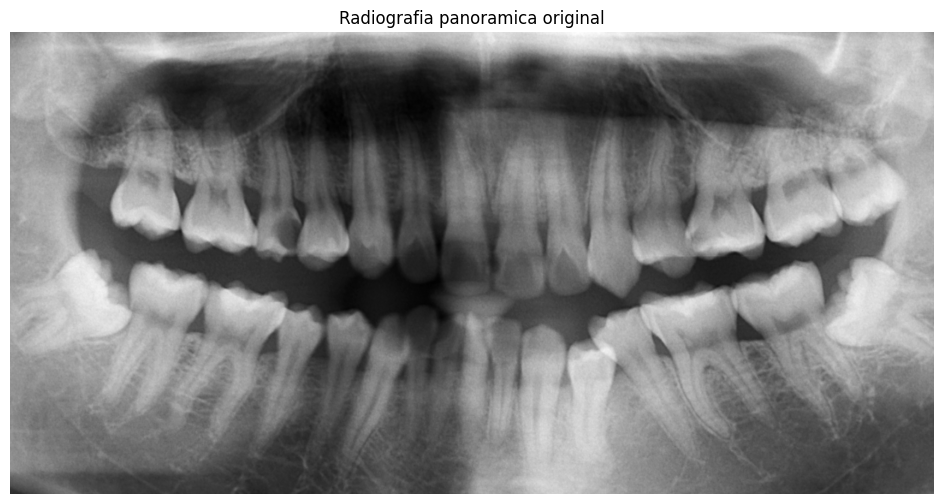

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests



# URL de una radiografia panoramica de ejemplo
url = 'https://raw.githubusercontent.com/Zzz512/MLUA/main/dataset/test/images_cut/1008.png'


# Descargar la imagen y guardarla localmente
resp = requests.get(url)
with open('radiografia.png', 'wb') as f:
    f.write(resp.content)


# Cargar la imagen con OpenCV (BGR por defecto)
img = cv2.imread('radiografia.png')
print('Dimensiones de la imagen:', img.shape)


#Mostrar imagen
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.title('Radiografia panoramica original')
plt.axis('off')
plt.show()

## Recorte de una region de interes (ROI)

Trabajar sobre toda la radiografia panoramica introduce demasiado ruido (hueso, espacios de aire, bordes de la mandibula).
Recortamos una region con varios dientes para que la deteccion sea mas confiable.

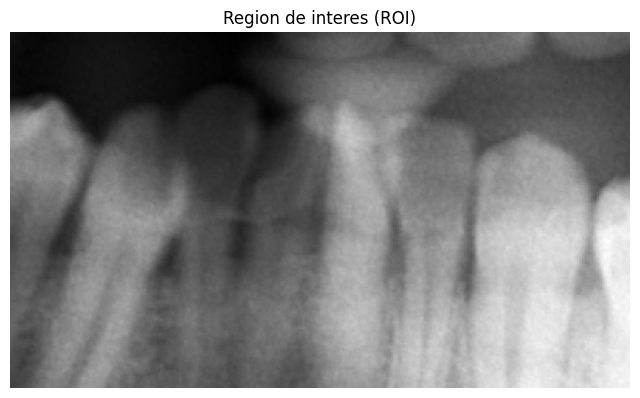

In [2]:
# Convertir a escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)



# Recortar una region con varios dientes (alto, ancho)
roi = gray[420:650, 550:950]

 #Mostrar imagen
plt.figure(figsize=(8, 5))
plt.imshow(roi, cmap='gray')
plt.title('Region de interes (ROI)')
plt.axis('off')
plt.show()

## Preprocesamiento



Las radiografias dentales suelen tener bajo contraste, por lo que antes de buscar bordes o circulos conviene resaltar las diferencias de intensidad.

Usamos dos pasos adicionales a los vistos en clase:

- **CLAHE** (`cv2.createCLAHE`): una version de ecualizacion de histograma que trabaja por regiones (`tileGridSize`) en vez de sobre toda la imagen, lo cual evita saturar zonas ya claras u oscuras. `clipLimit` controla que tanto se permite exagerar el contraste antes de recortar el histograma.

- **Desenfoque Gaussiano** (`cv2.GaussianBlur`): igual que con las monedas, suaviza textura fina (ruido del sensor, textura ósea) para que Canny/Hough no la confundan con bordes reales.

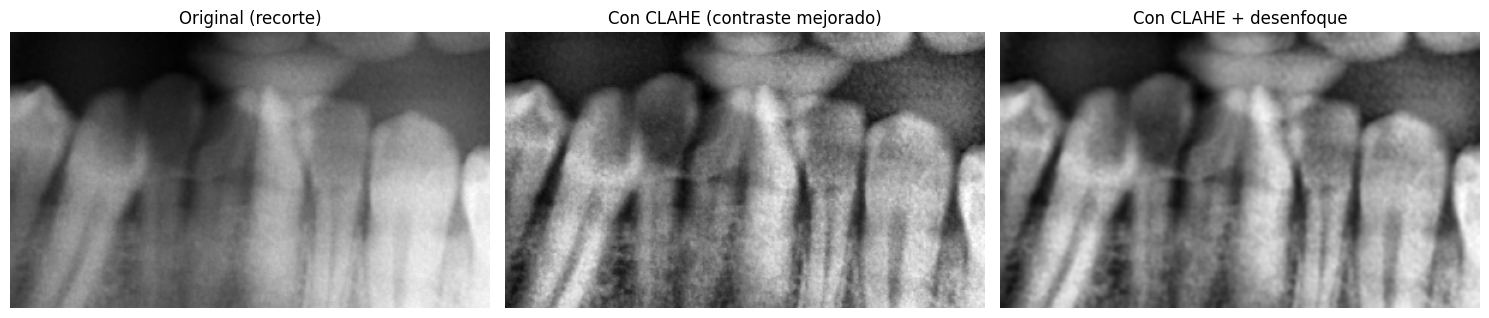

In [3]:
# Mejorar el contraste local con CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced = clahe.apply(roi)

# Suavizar para reducir ruido antes de la deteccion de bordes/circulos
blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

#Mostrar imagen

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(roi, cmap='gray')
axes[0].set_title('Original (recorte)')
axes[0].axis('off')

axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('Con CLAHE (contraste mejorado)')
axes[1].axis('off')

axes[2].imshow(blurred, cmap='gray')
axes[2].set_title('Con CLAHE + desenfoque')
axes[2].axis('off')


plt.tight_layout()
plt.show()

## Metodo A: Hough Circles (igual que el ejemplo de las monedas)


Aplicamos `cv2.HoughCircles` directamente, tal como se hizo con las monedas. La diferencia principal esta en los parametros `minRadius` y `maxRadius`, que aqui se ajustan a un tamaño de lesion mucho mas pequeño que una moneda, y en `param2`, que se baja un poco porque las lesiones tienen bordes menos definidos que una moneda fisica.

Circulos detectados con Hough: 5
Centros (x, y, radio): [(52, 165, 19), (344, 91, 17), (285, 77, 15), (82, 205, 11), (197, 57, 8)]


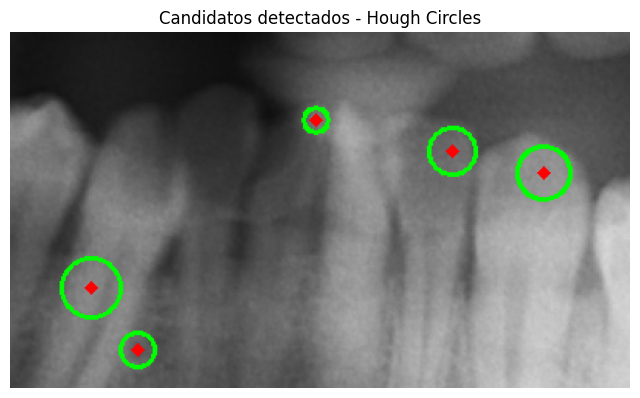

In [4]:
roi_color = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)
img_hough = roi_color.copy()


circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,        # resolucion del acumulador respecto a la imagen
    minDist=20,     # distancia minima entre centros de circulos distintos
    param1=60,      # umbral alto usado internamente por Canny
    param2=25,      # que tan seguro debe estar el algoritmo (mas bajo = mas circulos, mas falsos positivos)
    minRadius=5,    # radio minimo esperado de una lesion, en pixeles
    maxRadius=20     # radio maximo esperado de una lesion, en pixeles

)



centros_hough = []

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x, y, r in circles[0, :]:
        cv2.circle(img_hough, (x, y), r, (0, 255, 0), 2)   # contorno del circulo
        cv2.circle(img_hough, (x, y), 2, (0, 0, 255), 3)   # marca del centro
        centros_hough.append((int(x), int(y), int(r)))


print(f'Circulos detectados con Hough: {len(centros_hough)}')
print('Centros (x, y, radio):', centros_hough)



plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img_hough, cv2.COLOR_BGR2RGB))
plt.title('Candidatos detectados - Hough Circles')
plt.axis('off')
plt.show()

## Metodo B: umbral + contornos + filtro de circularidad


Las lesiones reales rara vez son circulos perfectos, asi que un segundo enfoque -mas flexible- es:

1. **Umbralizar** la imagen para separar zonas oscuras (posibles lesiones) del resto, usando el metodo de Otsu (`cv2.THRESH_OTSU`), que elige el umbral automaticamente en vez de fijarlo a mano como se hizo en clase con el valor 127.

2. **Limpiar** el resultado con una apertura morfologica (`cv2.morphologyEx`, `MORPH_OPEN`), que elimina puntos sueltos muy pequenos (ruido).

3. **Encontrar contornos** (`cv2.findContours`) de cada mancha resultante.

4. **Filtrar por forma**: calculamos que tan "redondo" es cada contorno con la formula de circularidad `4 * pi * area / perimetro^2` (vale 1 para un circulo perfecto, y baja mientras mas irregular es la forma), y descartamos los contornos demasiado pequenos, demasiado grandes o poco circulares.

5. Para cada contorno que pasa el filtro, `cv2.minEnclosingCircle` nos da el circulo mas pequeno que lo contiene por completo, del cual tomamos el centro.

Candidatos detectados con contornos + circularidad: 4
Centros (x, y, circularidad): [(286, 221, 0.63), (270, 130, 0.87), (236, 75, 0.85), (230, 51, 0.76)]


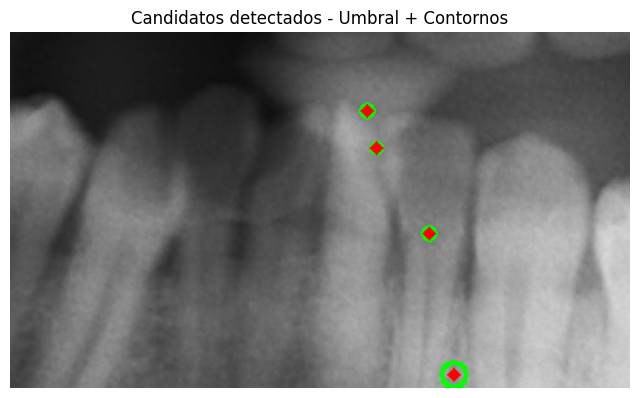

In [5]:
# Umbralizacion automatica (Otsu) - separa zonas oscuras del resto
_, binaria = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)



# Limpieza morfologica: elimina puntos sueltos muy pequenos
kernel = np.ones((3, 3), np.uint8)
binaria_limpia = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel, iterations=1)


# Encontrar los contornos de las zonas oscuras candidatas
contornos, _ = cv2.findContours(binaria_limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contornos = roi_color.copy()
centros_contornos = []


for c in contornos:
    area = cv2.contourArea(c)
    perimetro = cv2.arcLength(c, True)
    if area < 15 or perimetro == 0:

        continue  # descartar ruido demasiado pequeno

    circularidad = 4 * np.pi * area / (perimetro ** 2)

    # Nos quedamos solo con manchas de tamano razonable y forma suficientemente redonda

    if 15 < area < 400 and circularidad > 0.5:

        (x, y), r = cv2.minEnclosingCircle(c)

        cv2.circle(img_contornos, (int(x), int(y)), int(r), (0, 255, 0), 2)
        cv2.circle(img_contornos, (int(x), int(y)), 2, (0, 0, 255), 3)
        centros_contornos.append((int(x), int(y), round(circularidad, 2)))



print(f'Candidatos detectados con contornos + circularidad: {len(centros_contornos)}')
print('Centros (x, y, circularidad):', centros_contornos)


plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img_contornos, cv2.COLOR_BGR2RGB))
plt.title('Candidatos detectados - Umbral + Contornos')
plt.axis('off')
plt.show()

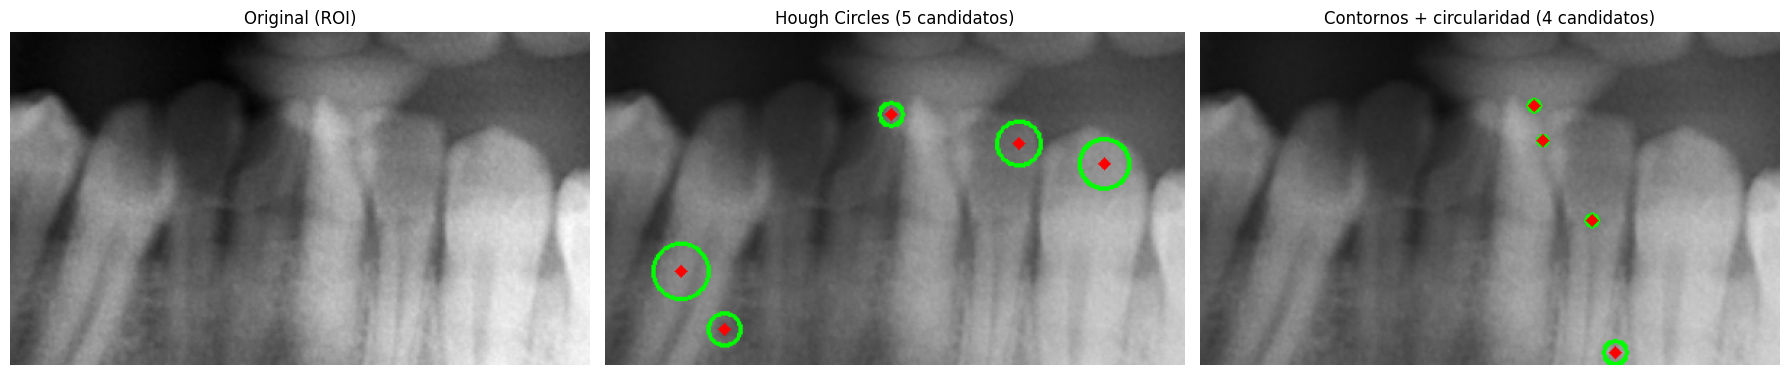

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))



axes[0].imshow(roi, cmap='gray')
axes[0].set_title('Original (ROI)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_hough, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Hough Circles ({len(centros_hough)} candidatos)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(img_contornos, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Contornos + circularidad ({len(centros_contornos)} candidatos)')
axes[2].axis('off')

plt.tight_layout()
plt.show()